# Proyecto 2: Escenarios empíricos de sismo en Occidente
Tania Tapia  

En este proyecto aplico lo visto en clase: **Monte Carlo** (con remuestreo), **bootstrapping** y una **búsqueda en malla**. Trabajo con el catálogo del SSN para comparar localidades de Occidente (Jalisco y zona vecina).


## Objetivo
- Estimar el riesgo anual de que ocurra **≥1 sismo** con magnitud **M ≥ M_min** dentro de la region de interés.
- Comparar la **severidad relativa** por localidad usando un índice simple basado en magnitud y distancia.
- Probar una **política de presupuesto** por localidad con una búsqueda en malla didáctica.


## Alcance y supuestos
- Datos del **SSN** (archivo del catálogo). Tomo una **región rectangular** que cubre Jalisco y estados vecinos (Nayarit, Colima, Michoacán).
- Región de interés (ROI) rectangular en Occidente (Jalisco + zonas vecinas). Umbral por defecto **M_min = 5.5**.
- **Conteo anual y severidad** se obtienen **solo del histórico** con remuestreo (no asumo Poisson ni otra distribución teórica).
- Índice didáctico por localidad:  
$$
I = M - \log_{10}(d_{km} + 1)  
 $$
(no es una GMPE; sirve para comparar escenarios de forma sencilla).


## Parámetros principales
- ROI: lat ∈ [18.0, 23.5], lon ∈ [-107.0, -100.0].
- Umbral de magnitud (M_min) por defecto: **5.5**.
- Localidades: **Guadalajara, Puerto Vallarta, Tepic, Colima, Manzanillo**.
- Repeticiones Monte Carlo: **N = 10 000**.


In [1]:
# Cargar el catálogo del SSN
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2, log10

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
csv_path = "/content/drive/MyDrive/Simulación Matematica/SSNMX_catalogo_20201029_20251029.csv"
ssn = pd.read_csv(csv_path, skiprows=4)
ssn.head()


# Limpieza básica
ssn['Fecha'] = pd.to_datetime(ssn['Fecha'], errors='coerce')
ssn = ssn.dropna(subset=['Fecha','Magnitud','Latitud','Longitud']).copy()
ssn = ssn.sort_values('Fecha')
len(ssn), ssn.columns.tolist()

Mounted at /content/drive


(153591,
 ['Fecha',
  'Hora',
  'Magnitud',
  'Latitud',
  'Longitud',
  'Profundidad',
  'Referencia de localizacion',
  'Fecha UTC',
  'Hora UTC',
  'Estatus'])

In [24]:
# Definir ROI
LAT_MIN, LAT_MAX = 18.0, 23.5
LON_MIN, LON_MAX = -107.0, -100.0

roi = ssn[(ssn['Latitud'].between(LAT_MIN, LAT_MAX)) &
          (ssn['Longitud'].between(LON_MIN, LON_MAX))].copy()
print("Eventos totales del catálogo:", len(ssn))
print("Eventos en el ROI (Occidente):", len(roi))
roi.head()

#solo se muestran las primeras 5 filas de los eventos de la region de interes para tener una idea de como se ven los datos

Eventos totales del catálogo: 153591
Eventos en el ROI (Occidente): 28690


,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
71,2020-10-29,18:36:40,2.2,22.7318,-102.564,2.0,"5 km al SUR de ZACATECAS, ZAC",2020-10-30,00:36:40,revisado
70,2020-10-29,18:32:34,2.0,22.7807,-102.616,2.0,"4 km al OESTE de ZACATECAS, ZAC",2020-10-30,00:32:34,revisado
68,2020-10-29,17:33:02,3.4,20.2298,-105.055,10.0,"46 km al SURESTE de PUERTO VALLARTA, JAL",2020-10-29,23:33:02,revisado
60,2020-10-29,15:40:27,3.7,19.3122,-103.972,78.9,"21 km al NOROESTE de COQUIMATLAN, COL",2020-10-29,21:40:27,revisado
59,2020-10-29,15:01:01,3.8,18.6258,-103.998,10.0,"34 km al SUROESTE de TECOMAN, COL",2020-10-29,21:01:01,revisado


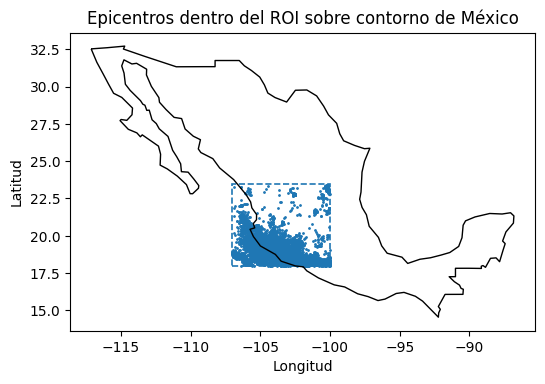

In [26]:
# Mapa de epicentros
!pip -q install geopandas

import geopandas as gpd, matplotlib.pyplot as plt, matplotlib.patches as mpatches

# Shapefile de México
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
mex = world[world["ADMIN"] == "Mexico"]

#Epicentros
gpoints = gpd.GeoDataFrame(
    roi.copy(),
    geometry=gpd.points_from_xy(roi["Longitud"], roi["Latitud"]),
    crs="EPSG:4326"
)

#Mapa
fig, ax = plt.subplots(figsize=(6,6))
mex.boundary.plot(ax=ax, linewidth=1, color="k")
gpoints.plot(ax=ax, markersize=1)

import matplotlib.patches as mpatches
rect = mpatches.Rectangle(
    (LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
    fill=False, linestyle="--", linewidth=1.2, edgecolor="tab:blue"
)
ax.add_patch(rect)

ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title("Epicentros dentro del ROI sobre contorno de México")
plt.show()



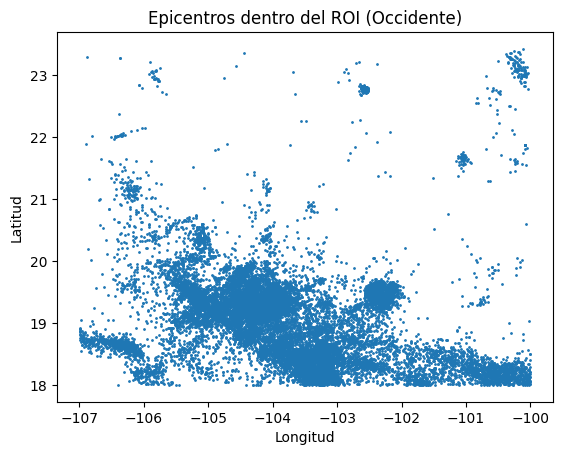

In [9]:
#Aqui es como un close up donde podemos ver de mejor manera los epicentros en ROI
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(roi["Longitud"], roi["Latitud"], s=1)
plt.title("Epicentros dentro del ROI (Occidente)")
plt.xlabel("Longitud"); plt.ylabel("Latitud")
plt.show()


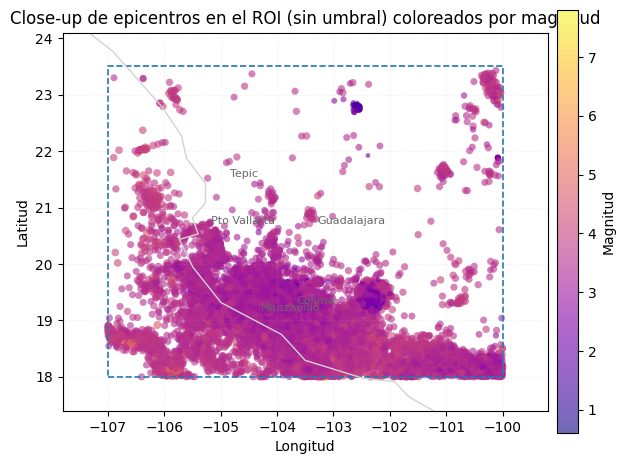

In [84]:
#Close-up del ROI: epicentros SIN umbral, coloreados por magnitud
!pip -q install geopandas shapely

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Data del ROI (sin umbral)
df_plot = roi.copy()
mags = df_plot["Magnitud"].astype(float).to_numpy()

# Contorno de México (Natural Earth)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
mex = world[world["ADMIN"] == "Mexico"]

# Tamaños y rango de color (ajustables)
s_base = 2        # tamaño base (más chico)
s_esc  = 8        # escala con magnitud
vmin_color = float(min(3.0, np.nanmin(mags)))
vmax_color = float(max(7.8, np.nanmax(mags)))

# Padding para el zoom del ROI (en grados)
pad_lon = 0.8
pad_lat = 0.6

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Contorno de México para referencia
mex.boundary.plot(ax=ax, linewidth=1, color="lightgray")

# Puntos (epicentros) coloreados por magnitud
sc = ax.scatter(
    df_plot["Longitud"], df_plot["Latitud"],
    c=mags,
    s=s_base + s_esc*(mags - np.nanmin(mags)),
    alpha=0.8, cmap="plasma",
    edgecolors="none"
)
sc.set_clim(vmin=vmin_color, vmax=vmax_color)

# Rectángulo del ROI
rect = mpatches.Rectangle(
    (LON_MIN, LAT_MIN),
    LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
    fill=False, linestyle="--", linewidth=1.2, edgecolor="tab:blue"
)
ax.add_patch(rect)

# Etiquetas de ciudades (lon, lat)
marcas = {
    "Guadalajara":  (-103.3496, 20.6597),
    "Pto Vallarta": (-105.2253, 20.6534),
    "Tepic":        (-104.9010, 21.5010),
    "Colima":       (-103.7240, 19.2452),
    "Manzanillo":   (-104.3421, 19.1138),
}
for nombre, (lon, lat) in marcas.items():
    ax.text(lon+0.06, lat+0.05, nombre, fontsize=8, color="dimgray")

# --- ZOOM: close-up al ROI con un pequeño margen ---
ax.set_xlim(LON_MIN - pad_lon, LON_MAX + pad_lon)
ax.set_ylim(LAT_MIN - pad_lat, LAT_MAX + pad_lat)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Close-up de epicentros en el ROI (sin umbral) coloreados por magnitud")
ax.grid(alpha=0.2, linestyle=":")

cbar = plt.colorbar(sc, ax=ax, pad=0.015)
cbar.set_label("Magnitud")

plt.show()


In [32]:
# Localidades a evaluar (lat, lon)
locales = {
    'Guadalajara': (20.6597, -103.3496),
    'Puerto Vallarta': (20.6534, -105.2253),
    'Tepic': (21.5010, -104.9010),
    'Colima': (19.2452, -103.7240),
    'Manzanillo': (19.1138, -104.3421)
}
#ditancia geodesica calculando la distancia en km entre 2 puntos
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0 # <-radio aproximado de la tierra en km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)  # <- corrección
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2*atan2(sqrt(a), sqrt(1-a))
    return R*c

    #comprobación
    # GDL ↔ Puerto Vallarta ≈ 180–220 km
print(haversine_km(20.6597, -103.3496, 20.6534, -105.2253))


# Distancias desde el primer evento del ROI a cada localidad
if not roi.empty:
    lat0, lon0 = roi.iloc[0]['Latitud'], roi.iloc[0]['Longitud']
    demo = {k: round(haversine_km(lat0, lon0, v[0], v[1]),1) for k,v in locales.items()}
    print (demo)
else:
    {}

195.16001805092108
{'Guadalajara': 244.3, 'Puerto Vallarta': 359.2, 'Tepic': 276.9, 'Colima': 406.0, 'Manzanillo': 442.6}


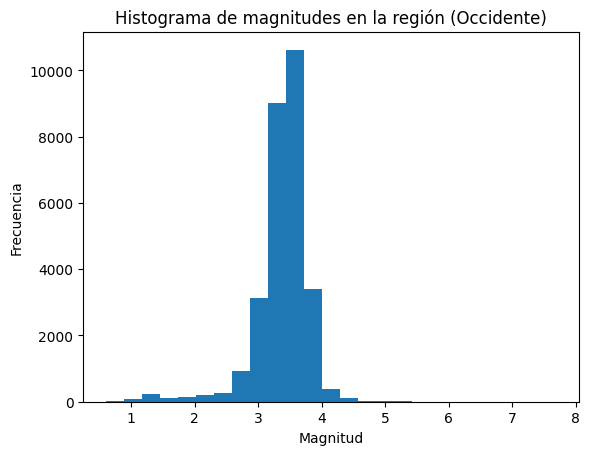

Años cubiertos: 2021 → 2025
Conteos (primeros 10):
2021    1
2022    2
2023    3
2024    2
2025    1


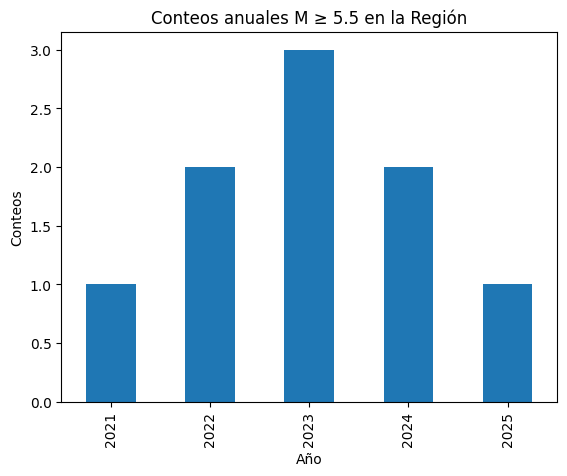

<Figure size 640x480 with 0 Axes>

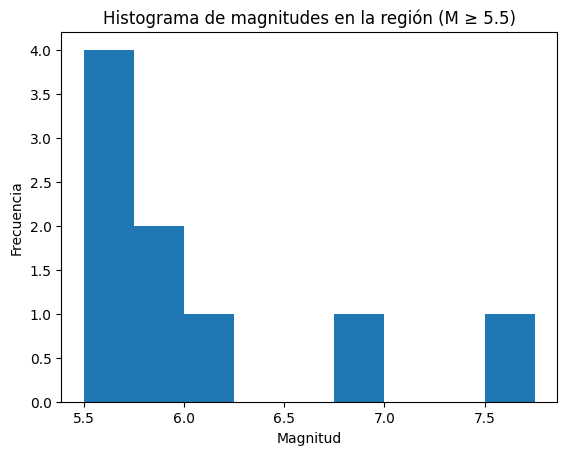

In [43]:
# Exploración simple:  histograma de magnitudes en el ROI, muestra todas las magnitudes de sismo dentro de la region sin tomar en ucenta el umbral o sea el limite minimo
plt.figure()
plt.hist(roi['Magnitud'].dropna(), bins=25)
plt.title("Histograma de magnitudes en la región (Occidente)")
plt.xlabel("Magnitud")
plt.ylabel("Frecuencia")
plt.show()

#Conteos Anuales para magnitud umbral
M_min = 5.5
roi_M = roi[roi['Magnitud'] >= M_min].copy()
roi_M['anio'] = roi_M['Fecha'].dt.year

years = roi_M['anio'].astype(int)
year_min, year_max = int(years.min()), int(years.max())

#Conteos anuales INCLUYENDO años con 0 eventos
all_years = pd.Series(0, index=range(year_min, year_max+1), dtype=int)
all_years.update(roi_M.groupby('anio').size())

conteos_vec = all_years.values.astype(int)

plt.figure()  # muestra cuantos sismos iguales o mayores al umbral (5.5) hubo por año dentro de la region
all_years.plot(kind='bar')
print("Años cubiertos:", all_years.index.min(), "→", all_years.index.max())
print("Conteos (primeros 10):")
print(all_years.head(10).to_string())
plt.title(f"Conteos anuales M ≥ {M_min} en la Región")
plt.xlabel("Año"); plt.ylabel("Conteos")
plt.show()

all_years.describe()

plt.figure()  #muestra solo las magnitudes grandes (>5.5)
bins = np.arange(M_min, roi_M['Magnitud'].max() + 0.25, 0.25)
plt.figure()
plt.hist(roi_M['Magnitud'].dropna(), bins=bins)
plt.title(f"Histograma de magnitudes en la región (M ≥ {M_min})")
plt.xlabel("Magnitud"); plt.ylabel("Frecuencia")
plt.show()



## Modelo
1. Armo la **distribución empírica** de **conteos anuales** (M ≥ M_min) en el ROI. Incluyo años con cero si en el rango hubo años sin eventos.
2. En cada réplica anual **muestreo** un conteo desde esa distribución.
3. Para cada evento del conteo muestreo (con reemplazo) un par **(magnitud, epicentro)** del histórico M ≥ M_min del ROI (**bootstrapping**).
4. Para cada localidad calculo la distancia y el **índice**
$$
I = M - \log_{10}\!\big(d_{\mathrm{km}}+1\big)
$$
5. De cada réplica guardo la **máxima magnitud** y el **máximo I** por localidad.


In [47]:
# Simulación Monte Carlo
N = 10000
rng = np.random.default_rng(2025)

if roi_M.empty:
    raise ValueError("No hay eventos M>=M_min en el ROI. Ajusta ROI o M_min.")

# Distribución empírica de conteos anuales
years = roi_M['anio'].astype(int)
year_min, year_max = years.min(), years.max()
all_years = pd.Series(0, index=range(year_min, year_max+1))
all_years.update(roi_M.groupby('anio').size())
conteos_vec = all_years.values  # vector de conteos por año

# Banco de eventos históricos para remuestreo
bank = roi_M[['Magnitud','Latitud','Longitud']].dropna().reset_index(drop=True)

# Contenedores
has_any = np.zeros(N, dtype=int)
max_M = np.zeros(N)
max_I_local = {loc: np.zeros(N) for loc in locales.keys()}

# Simulación
for i in range(N):
    n = int(rng.choice(conteos_vec))
    has_any[i] = (n >= 1)

    if n > 0:
        idx = rng.integers(0, len(bank), size=n)
        sample = bank.iloc[idx]
        Mvals = sample['Magnitud'].to_numpy(float)
        max_M[i] = Mvals.max()

        for loc, (latc, lonc) in locales.items():
            I_vals = []
            for _, r in sample.iterrows():
                d = haversine_km(latc, lonc, float(r['Latitud']), float(r['Longitud']))
                I = float(r['Magnitud']) - np.log10(d + 1.0)
                I_vals.append(I)
            max_I_local[loc][i] = max(I_vals) if I_vals else 0.0
    else:
        max_M[i] = 0.0

prob_any = has_any.mean()
print(f"Prob(≥1 evento en 12 meses): {prob_any:.3f}")


Prob(≥1 evento en 12 meses): 1.000


In [52]:
# Resúmenes por localidad y globales
def pct(x, p):
    return float(np.percentile(x, p)) if len(x)>0 else 0.0

tabla = []
for loc in locales.keys():
    I = max_I_local[loc]
    tabla.append([loc, pct(I,50), pct(I,95)])

res_local = pd.DataFrame(tabla, columns=['Localidad','max I - P50','max I - P95'])
res_local_sorted = res_local.sort_values('max I - P95', ascending=False).reset_index(drop=True)

resumen_global = pd.DataFrame({
    'Métrica': ['Prob(≥1 evento, 12 meses)', 'max M - P50', 'max M - P95'],
    'Valor': [prob_any, pct(max_M,50), pct(max_M,95)]
})

res_local_sorted, resumen_global

out = res_local_sorted.copy()
out["P50 de max I"] = out["max I - P50"].round(3)  #el valor “típico” del índice más alto que se espera en un año.
out["P95 de max I"] = out["max I - P95"].round(3) # valor que se supera 5% de los años segun el muestreo historico
out = out[["Localidad","P50 de max I","P95 de max I"]]

# mostrar tablas
display(out)

rg = resumen_global.copy()
rg["Valor"] = rg["Valor"].astype(float).round(3)
display(rg)




,Localidad,P50 de max I,P95 de max I
0,Colima,4.157,5.611
1,Manzanillo,4.046,5.523
2,Guadalajara,3.716,5.268
3,Puerto Vallarta,3.621,5.170
4,Tepic,3.537,5.096


,Métrica,Valor
0,"Prob(≥1 evento, 12 meses)",1.0
1,max M - P50,6.1
2,max M - P95,7.7


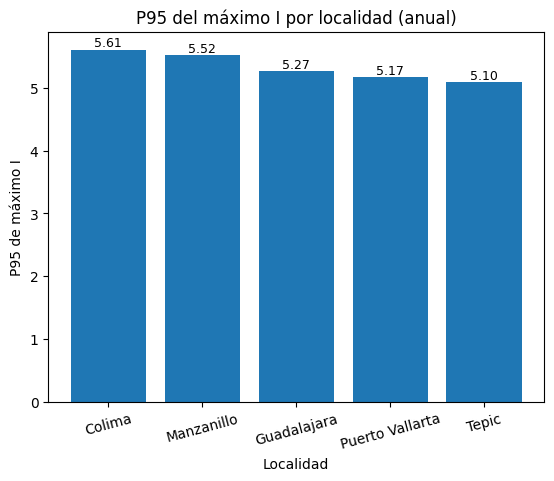

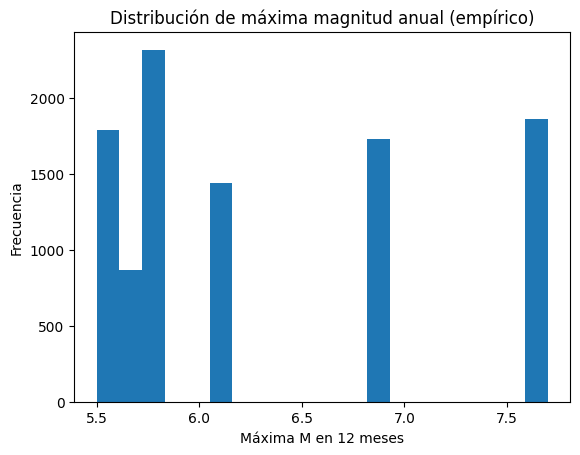

P50 max M: 6.1
P95 max M: 7.7


In [61]:
# Gráficos (una figura por gráfico)
plt.figure()
plt.bar(res_local_sorted['Localidad'], res_local_sorted['max I - P95'])
plt.title("P95 del máximo I por localidad (anual)")
plt.xlabel("Localidad")
plt.ylabel("P95 de máximo I")
plt.xticks(rotation=15)
vals = res_local_sorted['max I - P95'].values
for i,v in enumerate(vals):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

plt.show()

plt.figure()
plt.hist(max_M, bins=20)
plt.title("Distribución de máxima magnitud anual (empírico)")
plt.xlabel("Máxima M en 12 meses")
plt.ylabel("Frecuencia")

plt.show()
print("P50 max M:", np.percentile(max_M, 50).round(2))
print("P95 max M:", np.percentile(max_M, 95).round(2))


## Sensibilidad rápida
Pruebo M_min = **5.0** y M_min = **6.0** para ver cómo cambian Prob(≥1) y el P95 del índice por localidad.


In [67]:
def run_empirical(M_min_val, seed=2025):
    roi_Mx = roi[roi['Magnitud'] >= M_min_val].copy()
    if roi_Mx.empty:
        return None
    roi_Mx['anio'] = roi_Mx['Fecha'].dt.year
    years = roi_Mx['anio'].astype(int)
    year_min, year_max = years.min(), years.max()
    all_years = pd.Series(0, index=range(year_min, year_max+1))
    all_years.update(roi_Mx.groupby('anio').size())
    conteos_vec = all_years.values.astype(int)
    bankx = roi_Mx[['Magnitud','Latitud','Longitud']].dropna().reset_index(drop=True)
    if len(bankx)==0:
        return None
    N2 = 5000
    rng2 = np.random.default_rng(seed)
    has_any = np.zeros(N2, dtype=int)
    max_Ix = {loc: np.zeros(N2) for loc in locales.keys()}
    for i in range(N2):
        n = int(rng2.choice(conteos_vec))
        has_any[i] = (n>=1)
        if n>0:
            idx = rng2.integers(0, len(bankx), size=n)
            sample = bankx.iloc[idx]
            for loc, (latc, lonc) in locales.items():
                vals = []
                for _, r in sample.iterrows():
                    d = haversine_km(latc, lonc, float(r['Latitud']), float(r['Longitud']))
                    I = float(r['Magnitud']) - np.log10(d + 1.0)
                    vals.append(I)
                max_Ix[loc][i] = max(vals) if vals else 0.0
    def pct(x,p): return float(np.percentile(x,p))
    table = [[loc, pct(arr,95)] for loc, arr in max_Ix.items()]
    return has_any.mean(), pd.DataFrame(table, columns=['Localidad', f'P95 I (M≥{M_min_val})']).sort_values(f'P95 I (M≥{M_min_val})', ascending=False)

out_50 = run_empirical(5.0, seed=2025)
out_60 = run_empirical(6.0, seed=2025)


out_50, out_60

((np.float64(1.0),
           Localidad  P95 I (M≥5.0)
  3           Colima       5.610647
  4       Manzanillo       5.523259
  0      Guadalajara       5.267918
  1  Puerto Vallarta       5.169847
  2            Tepic       5.095795),
 (np.float64(0.4872),
           Localidad  P95 I (M≥6.0)
  3           Colima       5.610647
  4       Manzanillo       5.523259
  0      Guadalajara       5.267918
  1  Puerto Vallarta       5.169847
  2            Tepic       5.095795))

## Búsqueda en malla de presupuesto por localidad
Uso **$E[(max I)^2]$** como índice de daño esperado. Un presupuesto **B** reduce el daño por
$$
\alpha(B)=1/(1+kB)\
$$
El costo total:
$$
C_{loc}(B) = E[(\max I)^2]\cdot\alpha(B) + B
$$
Obtengo **B** en una malla de 0 a 100.


In [68]:
k = 0.05
B_grid = np.linspace(0, 100, 51)
res_cost = []

for loc in locales.keys():
    Iarr = max_I_local[loc]
    E_damage = float(np.mean(np.maximum(Iarr, 0.0)**2))
    costos = []
    for B in B_grid:
        alpha = 1.0/(1.0 + k*B)
        C = E_damage*alpha + B
        costos.append(C)
    costos = np.array(costos)
    j = int(np.argmin(costos))
    res_cost.append([loc, E_damage, float(B_grid[j]), float(costos[j])])

tabla_B = pd.DataFrame(res_cost, columns=['Localidad','E[Daño] índice','B*','C(B*)']).sort_values('C(B*)').reset_index(drop=True)
tabla_B

,Localidad,E[Daño] índice,B*,C(B*)
0,Tepic,15.112425,0.0,15.112425
1,Guadalajara,15.673007,0.0,15.673007
2,Puerto Vallarta,15.973153,0.0,15.973153
3,Colima,17.838518,0.0,17.838518
4,Manzanillo,17.989090,0.0,17.989090


### Nota sobre la búsqueda en malla de presupuesto \(B\)

Uso un índice de daño esperado
$$
E \;=\; \mathbb{E}\!\left[(\max I)^2\right].
$$

Supongo que un presupuesto \(B\) reduce el daño con
$$
\alpha(B) \;=\; \frac{1}{1+kB}.
$$

Entonces, el costo total por localidad es
$$
C(B) \;=\; E\,\alpha(B) + B \;=\; \frac{E}{1+kB} + B.
$$

Con \(k=0.05\) y los valores estimados de \(E\), se cumple $kE \leq 1$ en todas las localidades; en ese caso el mínimo de \(C(B)\) cae en el borde
$$
B^{\star} \;=\; 0.
$$

**Fórmula general del óptimo (si no hay cota inferior):**
$$
B^{\star} \;=\; \max\!\left\{\,0,\ \frac{\sqrt{kE}-1}{k}\right\}.
$$

**Interpretación.** Con \(k=0.05\) la efectividad del presupuesto es baja; por eso el óptimo es $B^{\star}=0\$. La priorización entre ciudades se basa en:

- **P95 del $\max I$** (nivel alto pero aún probable), y
- **Daño esperado** $E=\mathbb{E}[(\max I)^2]$


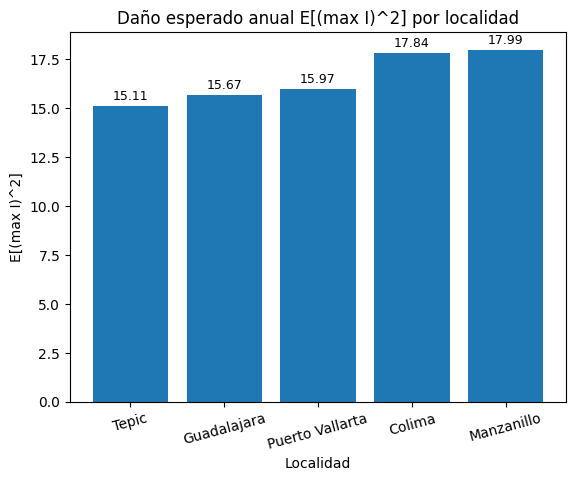

In [76]:
# ordenar de menor a mayor indice de daño
tmp = tabla_B.sort_values('C(B*)', ascending=True)

plt.figure()
tmp = tabla_B.sort_values('C(B*)', ascending=True)
plt.bar(tmp['Localidad'], tmp['C(B*)'])
plt.title("Daño esperado anual E[(max I)^2] por localidad")  # <- opción 1
plt.xlabel("Localidad")
plt.ylabel("E[(max I)^2]")  # más preciso que C(B*)
plt.xticks(rotation=15)

for i, v in enumerate(tmp['C(B*)']):
    plt.text(i, v + 0.15, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

plt.show()


## Conclusiones

- **Qué hice.** Construí un modelo 100% empírico (sin Poisson) para el occidente de México usando el catálogo del SSN (2020–2025).  
  - ROI: lat ∈ [18.0, 23.5], lon ∈ [−107, −100].  
  - Umbral base: $M_{\min}=5.5$  
  - Monte Carlo con remuestreo del histórico (10 000 réplicas) y un índice didáctico $I=M-\log_{10}(d+1)$  
  - Métricas por localidad: **P95 del $\max I$** y **daño esperado** $E[(\max I)^2]$.

- **Lo que encontré (comparación relativa).**  
  - Por **P95 del $max I$**: **Colima** > **Manzanillo** > **Guadalajara** > **Puerto Vallarta** > **Tepic**.  
  - Por **daño esperado** $E[(\max I)^2]$: **Manzanillo ≈ Colima** > **Puerto Vallarta ≈ Guadalajara** > **Tepic**.  
  - Interpretación: Colima/Manzanillo concentran escenarios “altos pero probables”; Tepic es el más bajo en esta ventana de datos.

- **Búsqueda de presupuesto.** Con \(k=0.05\) se cumple $kE \le 1$ en todas las ciudades, por lo que el costo se minimiza en **$B^{\star}=0$** y **$C(B^{\star}) = E[(\max I)^2]$**.  
  - En este esquema, **no conviene gastar** (el gasto no reduce lo suficiente el daño).  
  - La priorización de política se basa entonces en el **ranking de severidad** (P95 y \(E\)).

- **Sensibilidad.** Al cambiar $M_{\min}$ de 5.5 a 6.0:
  - La probabilidad de “≥1 evento” baja, pero **el orden relativo entre ciudades casi no cambia**.  
  - Señal: el ranking está dominado por la combinación magnitud–distancia del histórico.

- **Qué sí podemos afirmar.**  
  - Los resultados son **coherentes con el histórico** usado y sirven para **comparar entre ciudades** dentro del ROI y del periodo analizado.  
  - El enfoque de remuestreo es simple, transparente y reproducible en Colab.

- **Limitaciones.**  
  - $I$ es un **índice didáctico** (no es una GMPE) y **no incorpora** exposición ni vulnerabilidad.  
  - No se modela dependencia espacio-temporal (declustering, secuencias).  
  - La “efectividad” $k$ del presupuesto es supuesta; sin calibración con costos reales, la decisión $B^{\star}=0$ es solo **un ejercicio** del modelo.

**Cierre.**
Bajo este enfoque empírico, **Manzanillo y Colima** concentran la mayor severidad esperada; **Guadalajara y Puerto Vallarta** quedan en un nivel intermedio y **Tepic** en el más bajo. Con $k=0.05$ el óptimo presupuestal es $ B^{\star}=0 $, por lo que la recomendación es **priorizar monitoreo, preparación y atención** en Manzanillo/Colima y mantener seguimiento en el resto.
